In [22]:
import numpy as np
import pandas as pd
import pickle
import os
import random
from tqdm.auto import tqdm
import nlpaug.augmenter.char as nac
import faiss

TRAIN_BIO_PATH = "../../data/processed/train_bio.csv"
LIBRARY_PATH = "../../data/external/hybrid_library.pkl"
EMBEDDINGS_PATH = "../../data/external/embeddings/ru_en_aligned.pkl"

AUGMENTED_TRAIN_PATH = "../../data/processed/train_targeted_augmented_v1.csv"

print("--- Шаг 1: Загрузка данных и гибридной библиотеки ---")

try:
    df_train = pd.read_csv(TRAIN_BIO_PATH, sep=";")
    df_train["tokens"] = df_train["tokens"].apply(eval)
    df_train["tags"] = df_train["tags"].apply(eval)
    print(f"Загружено {len(df_train)} записей из train_bio.csv")

    with open(LIBRARY_PATH, 'rb') as f:
        master_artefacts = pickle.load(f)

    hybrid_library = master_artefacts['hybrid_library']
    golden_types = master_artefacts['golden_types']
    golden_brands = master_artefacts['golden_brands']

    print(f"Загружена гибридная библиотека с {len(hybrid_library)} контекстами.")
    print(f"Загружено {len(golden_types)} 'золотых' типов и {len(golden_brands)} 'золотых' брендов.")

except FileNotFoundError as e:
    print(f"Ошибка: Не найден необходимый файл. {e}")
    df_train = None

try:
    with open(EMBEDDINGS_PATH, 'rb') as f:
        embedding_dict = pickle.load(f)
    print(f"Загружен словарь эмбеддингов, содержащий {len(embedding_dict)} векторов.")

    words = list(embedding_dict.keys())
    id_to_word = {i: word for i, word in enumerate(words)}
    word_to_id = {word: i for i, word in enumerate(words)}

    embedding_dim = len(next(iter(embedding_dict.values())))
    embedding_matrix = np.zeros((len(words), embedding_dim), dtype='float32')
    for i, word in enumerate(words):
        embedding_matrix[i] = embedding_dict[word]

    faiss_index = faiss.IndexFlatL2(embedding_dim)
    faiss_index.add(embedding_matrix)

    print(f"FAISS индекс успешно создан. Проиндексировано {faiss_index.ntotal} векторов.")

except FileNotFoundError as e:
    print(f"Ошибка: Не найден файл эмбеддингов по пути {EMBEDDINGS_PATH}. Поиск синонимов будет отключен.")
    faiss_index = None
    embedding_dict = None

print("\n--- Инициализация завершена ---")

--- Шаг 1: Загрузка данных и гибридной библиотеки ---
Загружено 23163 записей из train_bio.csv
Загружена гибридная библиотека с 497 контекстами.
Загружено 13648 'золотых' типов и 3748 'золотых' брендов.
Загружен словарь эмбеддингов, содержащий 4122359 векторов.
FAISS индекс успешно создан. Проиндексировано 4122359 векторов.

--- Инициализация завершена ---


In [60]:
print("--- Шаг 2: Создание Ультимативного Арсенала Аугментаторов ---")

import re
from transliterate import translit


def augment_case(text: str) -> str:
    r = random.random()
    if r < 0.25: return text.lower()
    if r < 0.5: return text.upper()
    if r < 0.75: return text.title()
    return text


typo_augmenter = nac.KeyboardAug(aug_char_p=0.05, aug_word_p=0.1, include_special_char=False)


def augment_typos(text: str) -> str:
    result = typo_augmenter.augment(text)
    return result[0] if isinstance(result, list) else result


def augment_translit(text: str) -> str:
    if not re.search('[а-яА-Я]', text): return text
    try:
        return translit(text, 'ru', reversed=True)
    except Exception:
        return text


def augment_spacing(text: str) -> str:
    r = random.random()
    if r < 0.5:
        return text.replace(" ", "")
    else:
        return re.sub(r'(\d)([а-яА-Яa-zA-Z%])', r'\1 \2', text)


def augment_permutation(entities: list) -> list:
    permuted = entities[:]
    random.shuffle(permuted)
    return permuted


noise_words = [
    "купить", "продать", "цена", "стоимость", "недорого", "дёшево", "дорого",
    "онлайн", "интернет", "магазин", "доставка", "скидка", "акция", "распродажа",
    "найти", "искать", "заказать", "пожалуйста", "нужно", "хочу", "можно",
    "какой", "сколько", "где", "когда", "зачем", "почему", "как",
    "лучший", "хороший", "отличный", "свежий", "новый", "старый",

    "в", "на", "по", "с", "к", "из", "от", "до", "за", "через", "над", "под",
    "между", "около", "у", "при", "без", "после", "для", "о",

    "и", "а", "но", "или", "так", "чтобы", "если", "хотя", "потому", "что",
    "как", "также",

    "я", "ты", "он", "она", "оно", "мы", "вы", "они", "мой", "твой", "его",
    "её", "наш", "ваш", "их", "себя", "кто", "что", "где", "когда", "зачем",
    "кто-то", "что-то", "каждый", "весь", "всякий", "любой", "сам",

    "не", "ни", "да", "нет", "вот", "вон", "же", "ли", "только", "уже",
    "ещё", "очень", "совсем", "просто", "именно", "всё", "всё-таки", "ну",

    "быть", "есть", "был", "была", "были", "будет", "будут", "стать", "стало",

    "это", "эти", "тот", "та", "те", "тут", "там", "сейчас", "сегодня", "вчера",
    "завтра"
]


def augment_add_noise(entities: list) -> list:
    if not noise_words:
        return entities
    noisy_entities = entities[:]
    insert_position = random.randint(0, len(noisy_entities))
    noisy_entities.insert(insert_position, (random.choice(noise_words), 'O'))
    return noisy_entities


print("Функции-аугментаторы успешно определены.")

--- Шаг 2: Создание Ультимативного Арсенала Аугментаторов ---
Функции-аугментаторы успешно определены.


In [61]:
print("\n--- Шаг 3: Запуск 'Фабрики Синтетики' с Полным Конвейером Аугментаций ---")

synthetic_data = []
NUM_SYNTHETIC_SAMPLES = 27000

AUGMENTATION_PROBS = {
    "TYPE": 0.6,
    "BRAND": 0.7,
    "VOLUME": 0.8,
    "PERCENT": 0.8
}
PERMUTATION_PROB = 0.5
ADD_NOISE_PROB = 0.15
TRANSLIT_PROB = 0.2
TYPO_PROB = 0.5

eligible_categories = [cat for cat, data in hybrid_library.items() if data.get('volumes') or data.get('percents')]
print(f"Найдено {len(eligible_categories)} категорий, подходящих для генерации.")

templates = [
    ["TYPE", "BRAND", "VOLUME"], ["TYPE", "BRAND", "PERCENT"],
    ["BRAND", "TYPE", "VOLUME", "PERCENT"], ["TYPE", "VOLUME"],
    ["TYPE", "PERCENT"], ["BRAND", "TYPE"]
]

for _ in tqdm(range(NUM_SYNTHETIC_SAMPLES), desc="Генерация синтетики"):
    if not eligible_categories: break

    category_key = random.choice(eligible_categories)
    components = hybrid_library[category_key]
    entity_map = {"TYPE": category_key}

    if components.get('brands'): entity_map["BRAND"] = random.choice(components['brands'])

    use_volume = len(components.get('volumes', [])) > 0 and random.random() < 0.8
    use_percent = len(components.get('percents', [])) > 0 and random.random() < 0.6
    if use_volume: entity_map["VOLUME"] = random.choice(components['volumes'])
    if use_percent: entity_map["PERCENT"] = random.choice(components['percents'])
    if "VOLUME" not in entity_map and "PERCENT" not in entity_map:
        if components.get('volumes'):
            entity_map["VOLUME"] = random.choice(components['volumes'])
        elif components.get('percents'):
            entity_map["PERCENT"] = random.choice(components['percents'])
        else:
            continue

    available_labels = list(entity_map.keys())
    possible_templates = [t for t in templates if all(label in available_labels for label in t)]
    if not possible_templates: continue
    chosen_template = random.choice(possible_templates)

    query_entities = []
    for label in chosen_template:
        entity_text = entity_map[label]

        if random.random() < AUGMENTATION_PROBS.get(label, 0.3):
            augmented_text = entity_text

            if random.random() < TRANSLIT_PROB:
                augmented_text = augment_translit(augmented_text)
            else:
                augmented_text = augment_case(augmented_text)
                if random.random() < TYPO_PROB:
                    augmented_text = augment_typos(augmented_text)

            if label in ["VOLUME", "PERCENT"]:
                augmented_text = augment_spacing(augmented_text)

            query_entities.append((augmented_text, label))
        else:
            query_entities.append((entity_text, label))

    if len(query_entities) > 1 and random.random() < PERMUTATION_PROB:
        query_entities = augment_permutation(query_entities)

    if random.random() < ADD_NOISE_PROB:
        query_entities = augment_add_noise(query_entities)

    final_tokens, final_tags = [], []
    for text, label in query_entities:
        tokens = text.split() if label != 'O' else [text]
        if not tokens: continue

        if label != 'O':
            final_tags.append(f"B-{label}")
            final_tags.extend([f"I-{label}"] * (len(tokens) - 1))
        else:
            final_tags.extend(['O'] * len(tokens))

        final_tokens.extend(tokens)

    if final_tokens:
        synthetic_data.append({'tokens': final_tokens, 'tags': final_tags})

print(f"Сгенерировано {len(synthetic_data)} целевых синтетических примеров.")


--- Шаг 3: Запуск 'Фабрики Синтетики' с Полным Конвейером Аугментаций ---
Найдено 169 категорий, подходящих для генерации.


Генерация синтетики:   0%|          | 0/27000 [00:00<?, ?it/s]

Сгенерировано 27000 целевых синтетических примеров.


In [62]:
print("\n--- Шаг 4: Финальная сборка и сохранение датасета ---")

df_original = df_train[['tokens', 'tags']]
df_synthetic = pd.DataFrame(synthetic_data)

final_df = pd.concat([df_original, df_synthetic], ignore_index=True)

final_df = final_df[final_df['tokens'].apply(len) > 0]
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

final_df.to_csv(AUGMENTED_TRAIN_PATH, sep=";", index=False)

print(f"Финальный аугментированный датасет создан.")
print(f"  - Исходных примеров: {len(df_original)}")
print(f"  - Синтетических примеров: {len(df_synthetic)}")
print(f"  - Итоговый размер: {len(final_df)} примеров.")
print(f"Датасет сохранен в: {AUGMENTED_TRAIN_PATH}")


--- Шаг 4: Финальная сборка и сохранение датасета ---
Финальный аугментированный датасет создан.
  - Исходных примеров: 23163
  - Синтетических примеров: 27000
  - Итоговый размер: 50163 примеров.
Датасет сохранен в: ../../data/processed/train_targeted_augmented_v1.csv



--- Шаг 5: Финальный анализ распределения сущностей ---
Сравнение количества сущностей (B-тегов):
dataset  Аугментированный  Исходный
entity                             
BRAND                8450      6556
PERCENT              3657        29
TYPE                51688     24688
VOLUME              22553        67

График сравнения сохранен в: ../../reports/figures/targeted_augmentation_impact_v1.png


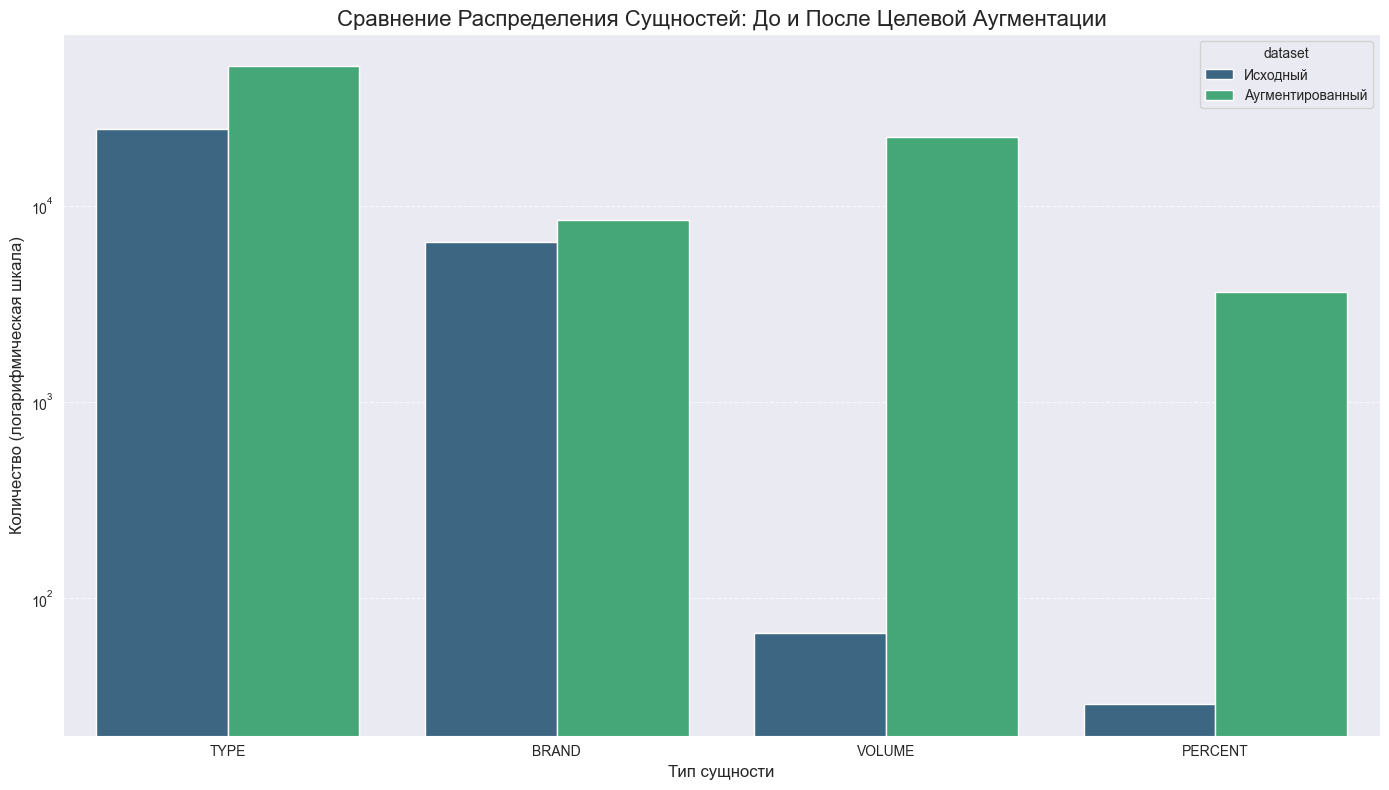

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("\n--- Шаг 5: Финальный анализ распределения сущностей ---")


def count_entities(df, name=""):
    """Подсчитывает количество B-тегов для каждого класса в датафрейме."""
    counts = Counter()
    for tags_list in df['tags']:
        for tag in tags_list:
            if tag.startswith("B-"):
                counts[tag[2:]] += 1

    df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).reset_index()
    df_counts = df_counts.rename(columns={'index': 'entity'})
    df_counts['dataset'] = name
    return df_counts


# Считаем сущности в исходном и финальном датасетах
original_counts_df = count_entities(df_train, name="Исходный")
final_counts_df = count_entities(final_df, name="Аугментированный")

# Объединяем для сравнения
comparison_df = pd.concat([original_counts_df, final_counts_df])

# Выводим точные цифры
print("Сравнение количества сущностей (B-тегов):")
print(comparison_df.pivot(index='entity', columns='dataset', values='count').fillna(0).astype(int))

# Визуализация
plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_df, x='entity', y='count', hue='dataset', palette='viridis')
plt.title('Сравнение Распределения Сущностей: До и После Целевой Аугментации', fontsize=16)
plt.xlabel('Тип сущности', fontsize=12)
plt.ylabel('Количество (логарифмическая шкала)', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Сохраняем график
output_chart_path = "../../reports/figures/targeted_augmentation_impact_v1.png"
os.makedirs(os.path.dirname(output_chart_path), exist_ok=True)
plt.savefig(output_chart_path)
print(f"\nГрафик сравнения сохранен в: {output_chart_path}")

plt.show()